In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/staff_turnover_HR_cleaned.csv')
df.head()

,EmpID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,AgeGroup,SalarySlab
0,RM650,53,No,Travel_Rarely,Research & Development,23,Life Sciences,4,Female,Research Director,...,3,3,33,0,3,12,9,3,46-55,10k-15k
1,RM015,28,Yes,Travel_Rarely,Research & Development,24,Life Sciences,3,Male,Laboratory Technician,...,3,2,6,4,3,4,2,0,26-35,Upto 5k
2,RM1111,35,Yes,Travel_Rarely,Research & Development,2,Life Sciences,1,Female,Laboratory Technician,...,3,4,1,2,3,1,0,0,26-35,Upto 5k
3,RM1438,39,No,Non_Travel,Research & Development,9,Life Sciences,4,Male,Manager,...,3,3,21,3,2,6,0,1,36-45,15k+
4,RM311,31,No,Travel_Rarely,Human Resources,2,Human Resources,1,Male,Human Resources,...,3,4,9,1,3,2,2,1,26-35,5k-10k


In [3]:
df_attrition = df.groupby('Attrition')['EmpID'].count().sort_values(ascending=False).reset_index(name='Cantidad')#.plot(kind='bar', color=['green', 'red'])
df_attrition

,Attrition,Cantidad
0,No,1236
1,Yes,237


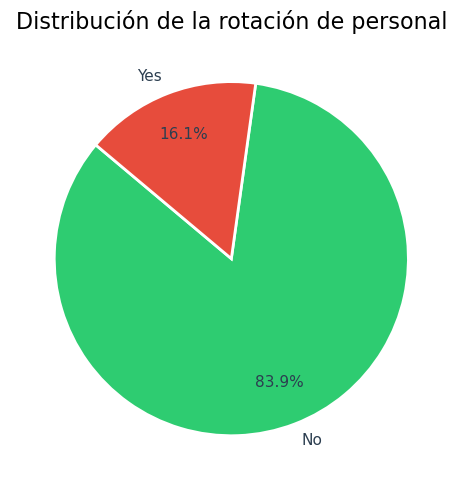

In [4]:
plt.figure(figsize=(6, 5))
colores = ["#2ecc71", "#e74c3c"]

wedges, texts, autotexts = plt.pie(
    df_attrition['Cantidad'],
    labels=df_attrition['Attrition'],
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    pctdistance=0.75,
    textprops={"fontsize": 11, "color": "#2C3E50"},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title('Distribución de la rotación de personal', fontsize=16)
plt.tight_layout() 
plt.show()


In [5]:
df_Department_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
df_Department_attrition = df_Department_attrition[['Yes']].style.format("{:.1%}")
df_Department_attrition

Attrition,Yes
Department,
Human Resources,19.0%
Research & Development,13.8%
Sales,20.6%


In [6]:
df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df_datos[['Yes']]
df_datos

Attrition,Yes
Department,
Human Resources,19.047619
Research & Development,13.811007
Sales,20.581655


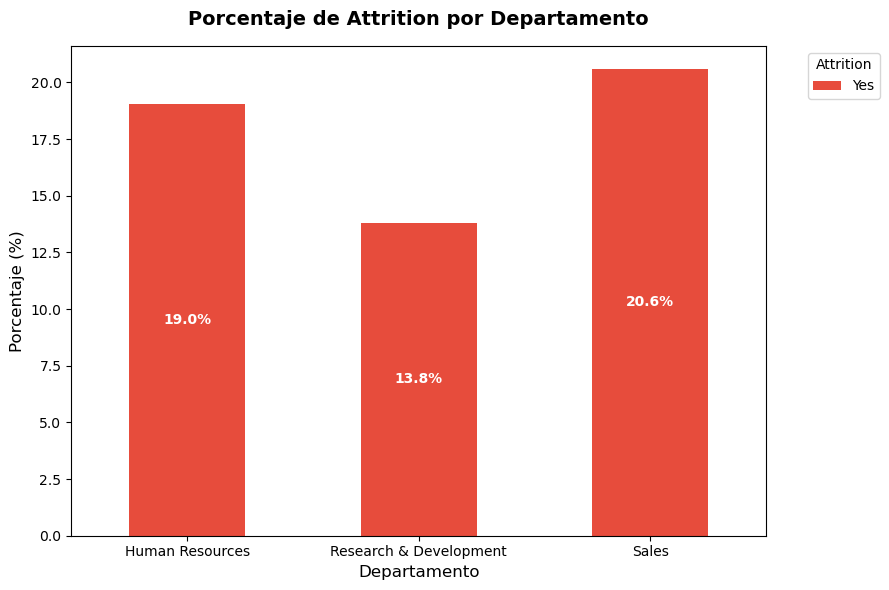

In [7]:
#df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
df_datos = df_datos[['Yes']]
ax = df_datos.plot(kind='bar', stacked=True, color=[ '#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Departamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [8]:
df_Gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack()
df_Gender_attrition = df_Gender_attrition.style.format("{:.1%}")
df_Gender_attrition

Attrition,No,Yes
Gender,,
Female,85.2%,14.8%
Male,83.0%,17.0%


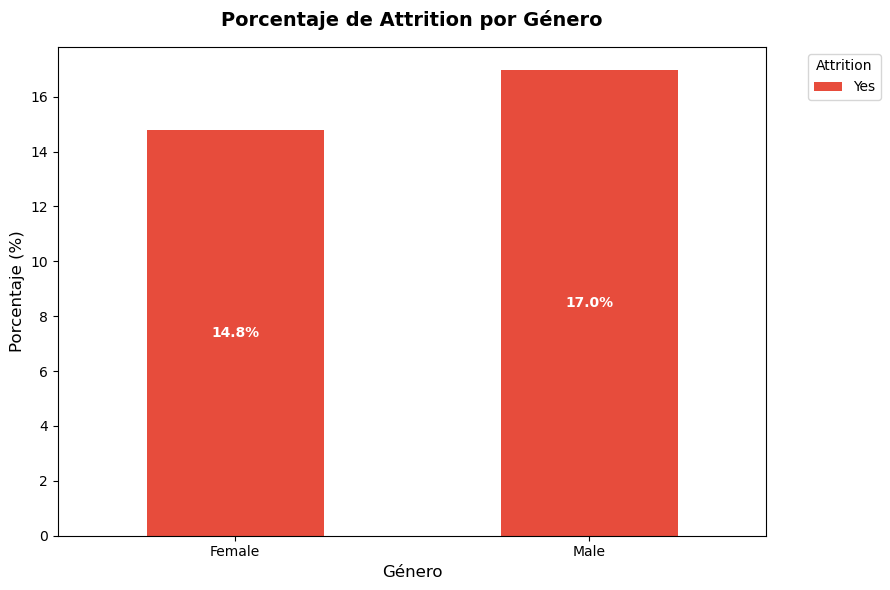

In [9]:
df_Gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack() * 100
df_Gender_attrition = df_Gender_attrition[['Yes']]

ax = df_Gender_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Género', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [10]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack()
df_jobrole_attrition = df_jobrole_attrition[['Yes']].style.format("{:.1%}")
df_jobrole_attrition

Attrition,Yes
JobRole,
Healthcare Representative,6.8%
Human Resources,23.1%
Laboratory Technician,23.9%
Manager,4.9%
Manufacturing Director,6.9%
Research Director,2.5%
Research Scientist,16.0%
Sales Executive,17.5%
Sales Representative,39.3%


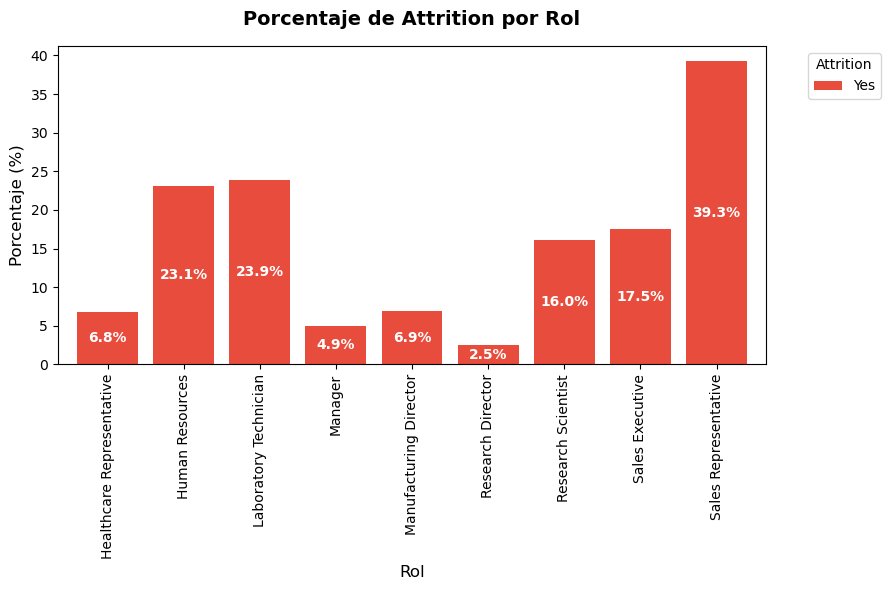

In [11]:
df_jobrole_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
df_jobrole_attrition = df_jobrole_attrition[['Yes']]
ax = df_jobrole_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Rol', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Rol', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=90) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [12]:
df_jobSatisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack()
df_jobSatisfaction_attrition = df_jobSatisfaction_attrition.style.format("{:.1%}")
df_jobSatisfaction_attrition

Attrition,No,Yes
JobSatisfaction,,
1,77.2%,22.8%
2,83.6%,16.4%
3,83.5%,16.5%
4,88.7%,11.3%


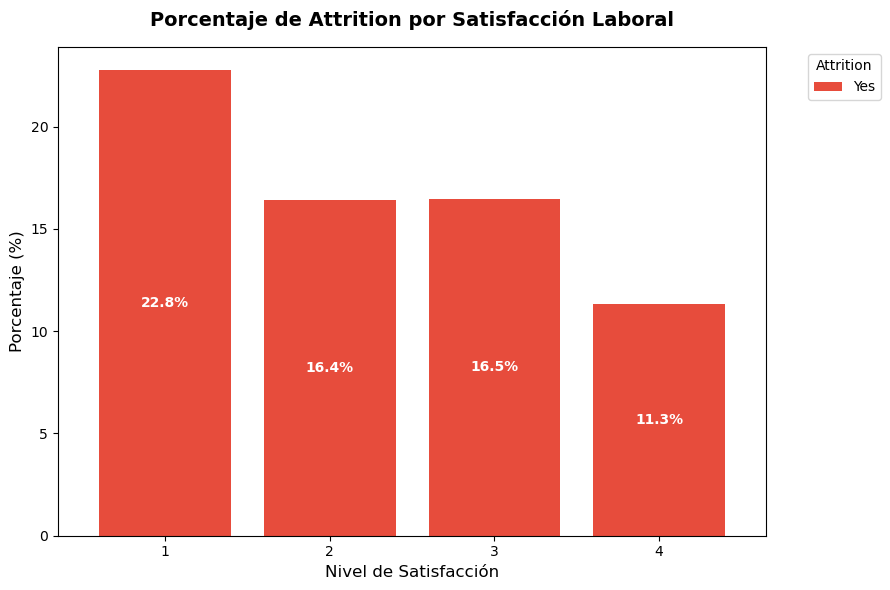

In [13]:
df_jobSatisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100
df_jobSatisfaction_attrition = df_jobSatisfaction_attrition[['Yes']]
ax = df_jobSatisfaction_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Satisfacción Laboral', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Satisfacción', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [14]:
df_maritalStatus_attrition = df.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True).unstack()
df_maritalStatus_attrition = df_maritalStatus_attrition.style.format("{:.1%}")
df_maritalStatus_attrition

Attrition,No,Yes
MaritalStatus,,
Divorced,89.1%,10.9%
Married,88.0%,12.0%
Single,74.5%,25.5%


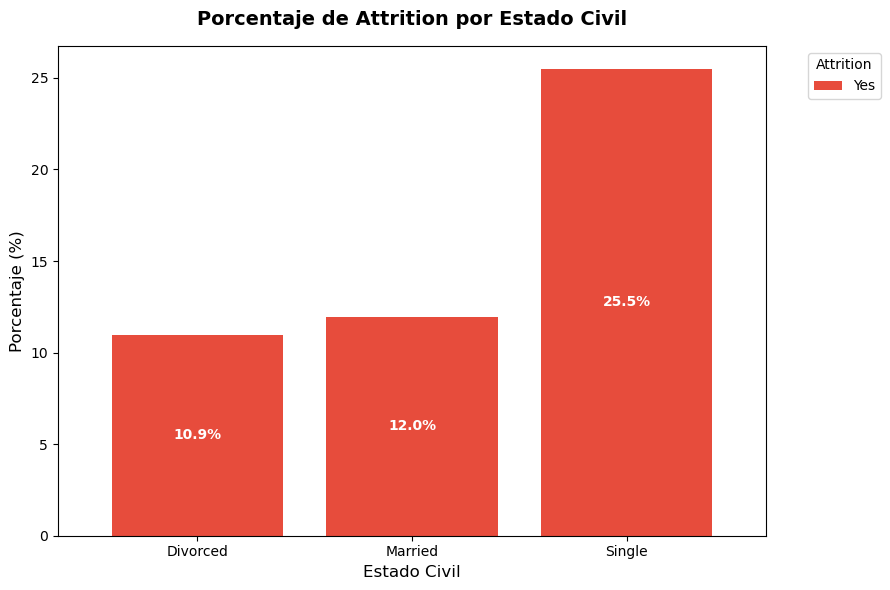

In [15]:
df_maritalStatus_attrition = df.groupby('MaritalStatus')['Attrition'].value_counts(normalize=True).unstack() * 100
df_maritalStatus_attrition = df_maritalStatus_attrition[['Yes']]
ax = df_maritalStatus_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Estado Civil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [16]:
df_salary_attrition = df.groupby('SalarySlab')['Attrition'].value_counts(normalize=True).unstack()
df_salary_attrition = df_salary_attrition.style.format("{:.1%}")
df_salary_attrition

Attrition,No,Yes
SalarySlab,,
10k-15k,86.5%,13.5%
15k+,96.2%,3.8%
5k-10k,88.9%,11.1%
Upto 5k,78.3%,21.7%


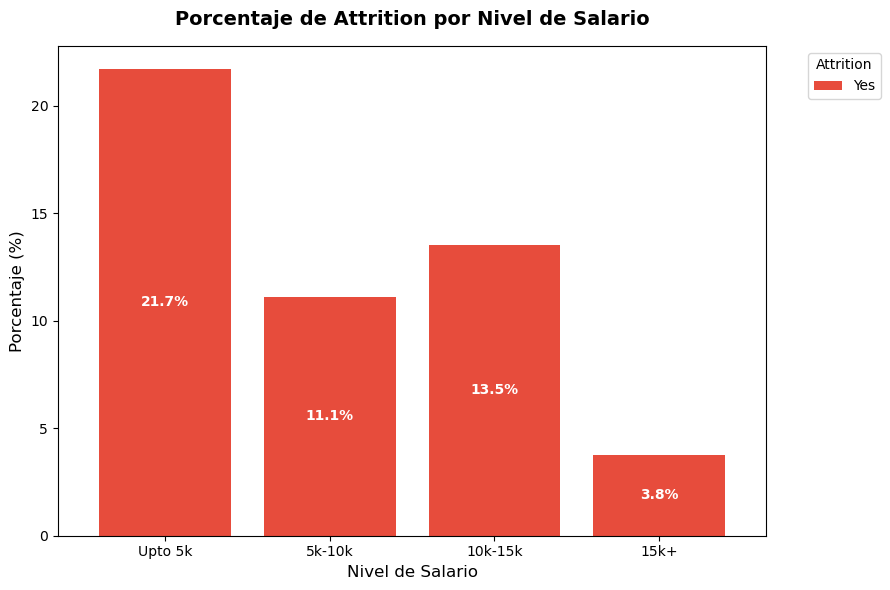

In [17]:
df_salary_attrition = df.groupby('SalarySlab')['Attrition'].value_counts(normalize=True).unstack() * 100
df_salary_attrition = df_salary_attrition[['Yes']]

orden_deseado = ['Upto 5k', '5k-10k', '10k-15k', '15k+']
df_salary_attrition = df_salary_attrition.reindex(orden_deseado)

ax = df_salary_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Nivel de Salario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Salario', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
df_age_attrition = df.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack()
df_age_attrition = df_age_attrition.style.format("{:.1%}")
df_age_attrition

Attrition,No,Yes
AgeGroup,,
18-25,64.2%,35.8%
26-35,80.9%,19.1%
36-45,90.9%,9.1%
46-55,88.5%,11.5%
55+,83.0%,17.0%


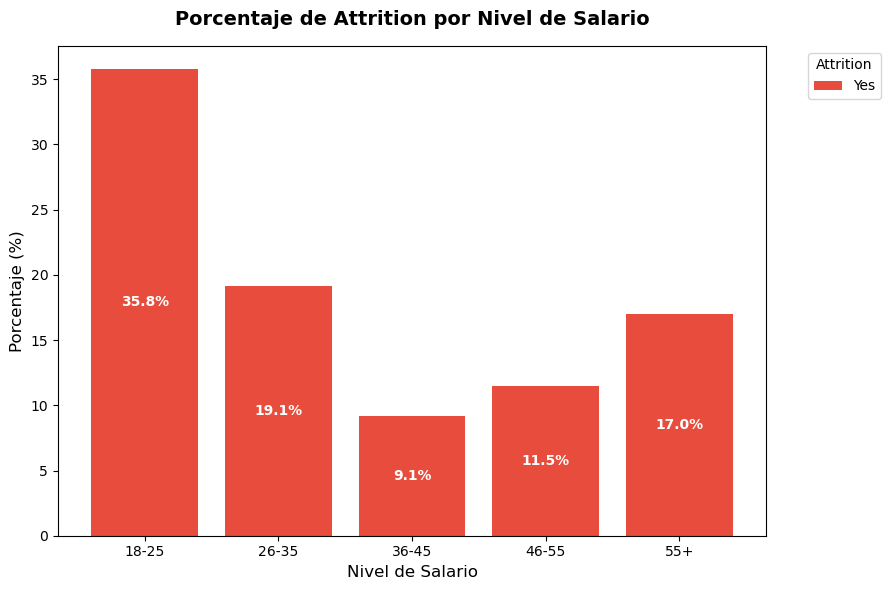

In [19]:
df_age_attrition = df.groupby('AgeGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_age_attrition =df_age_attrition[['Yes']]

ax = df_age_attrition.plot(kind='bar', stacked=True, color=['#e74c3c'], figsize=(9, 6), width=.8)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Porcentaje de Attrition por Nivel de Salario', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nivel de Salario', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
df_Age_Salary_attrition = df[['Age', 'MonthlyIncome', 'Attrition']]
df_Age_Salary_attrition

,Age,MonthlyIncome,Attrition
0,53,14275,No
1,28,2028,Yes
2,35,2074,Yes
3,39,19431,No
4,31,6410,No
...,...,...,...
1468,38,3306,No
1469,29,4319,No
1470,28,2909,Yes
1471,39,6120,No


In [21]:
df_Age_Salary_attrition=df_Age_Salary_attrition[df_Age_Salary_attrition['Attrition'] == 'Yes']
df_Age_Salary_attrition

,Age,MonthlyIncome,Attrition
1,28,2028,Yes
2,35,2074,Yes
6,30,2422,Yes
10,29,5765,Yes
18,33,5324,Yes
...,...,...,...
1447,49,4284,Yes
1448,28,9854,Yes
1452,40,13194,Yes
1459,28,2515,Yes


In [22]:
df_Age_Salary_attrition = df[['Age', 'MonthlyIncome', 'Attrition']]
df_Age_Salary_attrition=df_Age_Salary_attrition[df_Age_Salary_attrition['Attrition'] == 'Yes']
df_Age_Salary_attrition

,Age,MonthlyIncome,Attrition
1,28,2028,Yes
2,35,2074,Yes
6,30,2422,Yes
10,29,5765,Yes
18,33,5324,Yes
...,...,...,...
1447,49,4284,Yes
1448,28,9854,Yes
1452,40,13194,Yes
1459,28,2515,Yes


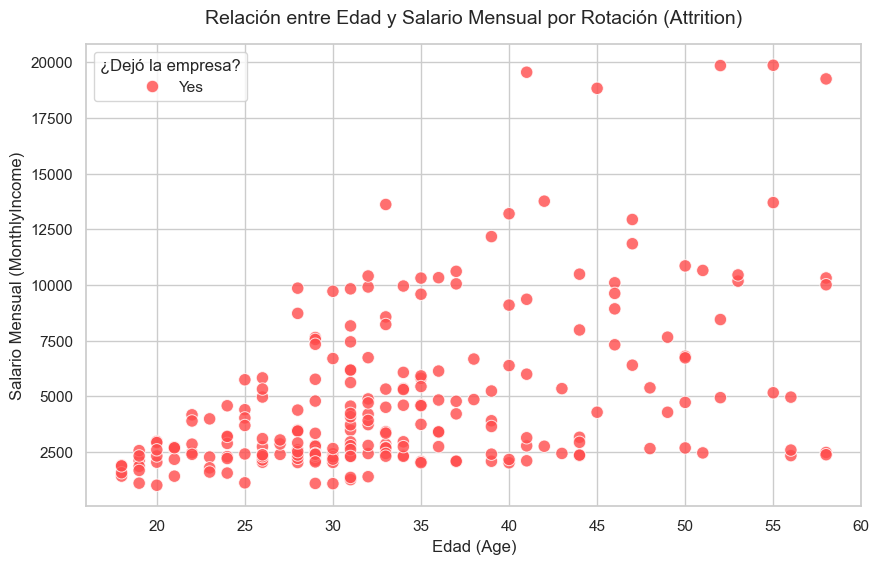

In [23]:

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_Age_Salary_attrition,
    x="Age",
    y="MonthlyIncome",
    hue="Attrition",
    palette={"Yes": "#FF4B4B", "No": "#1F77B4"},  # Rojo para Yes, Azul para No
    alpha=0.8,  # Hace los puntos un poco transparentes si se enciman
    s=80,  # Tamaño de los puntos
)

# 4. Personalizamos los textos del gráfico
plt.title(
    "Relación entre Edad y Salario Mensual por Rotación (Attrition)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Edad (Age)", fontsize=12)
plt.ylabel("Salario Mensual (MonthlyIncome)", fontsize=12)

# 5. Ajustamos la leyenda para que se vea ordenada
plt.legend(title="¿Dejó la empresa?")

# 6. Mostramos el gráfico en pantalla
plt.show()


In [24]:
df_overtime_attrition = (
    df.groupby('OverTime')['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

df_overtime_attrition[['Yes']]

Attrition,Yes
OverTime,
No,10.406812
Yes,30.528846


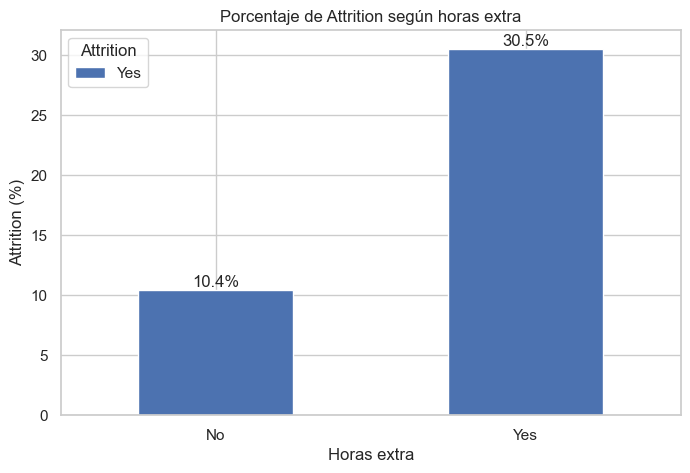

In [25]:
ax = df_overtime_attrition[['Yes']].plot(
    kind='bar',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge'
    )

plt.title('Porcentaje de Attrition según horas extra')
plt.xlabel('Horas extra')
plt.ylabel('Attrition (%)')
plt.xticks(rotation=0)
plt.show()

In [26]:
df.groupby('EnvironmentSatisfaction')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

EnvironmentSatisfaction
1    25.352113
2    14.982578
3    13.656388
4    13.392857
Name: Attrition, dtype: float64

In [27]:
satisfaction_vars = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance']

results = {}

for col in satisfaction_vars:
    results[col] = (
        df.groupby(col)['Attrition']
          .apply(lambda x: (x == 'Yes').mean() * 100)
    )

df_satisfaction = pd.DataFrame(results)

df_satisfaction

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance
1,25.352113,22.758621,20.577617,31.250000
2,14.982578,16.428571,14.851485,16.860465
3,13.656388,16.478555,15.434783,14.174107
4,13.392857,11.304348,14.780600,17.647059


## 💸💸💸**Analysis based on salary compensation**

### **Average Income**

In [28]:
MI_df = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'min', 'max'])
MI_df

,mean,median,min,max
Attrition,,,,
No,6828.718447,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


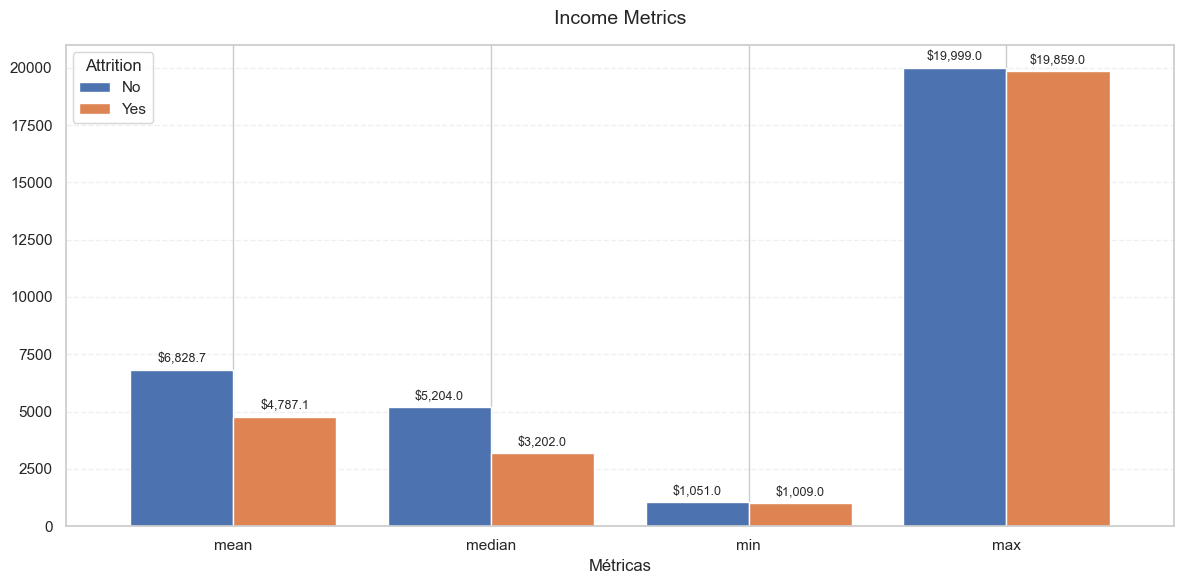

In [29]:
ax = MI_df.T.plot(kind='bar', figsize=(12, 6), width=0.8)

for contenedor in ax.containers:
    etiquetas = [f"${valor:,.1f}" for valor in contenedor.datavalues]
    ax.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=9)
    #ax.bar_label(contenedor, fmt='%.1f', padding=3, fontsize=9)

plt.title('Income Metrics', fontsize=14, pad=15)
plt.xlabel('Métricas', fontsize=12)
#plt.ylabel('Valores', fontsize=12)
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


The average, mean, minimum, and maximum income of employees who left the company were lower than the income of employees who did not leave.

In [30]:
medianas = df.groupby(["Attrition"])["MonthlyIncome"].median()
medianas

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64

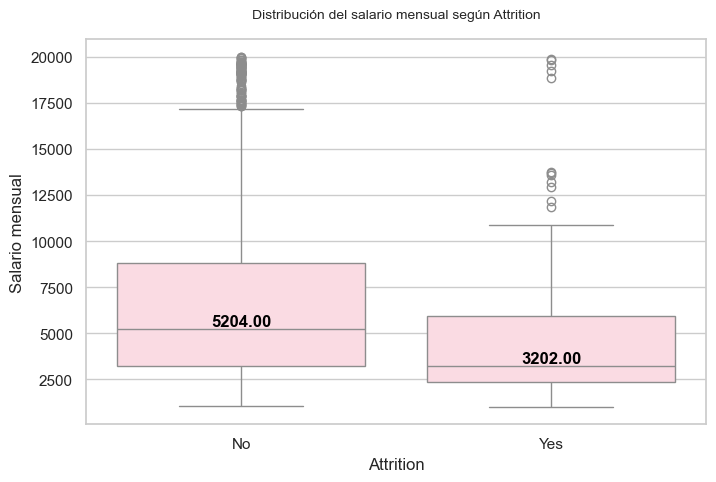

In [31]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", color="#FFD6E0")

medianas = df.groupby(["Attrition"])["MonthlyIncome"].median()

for i, valor in enumerate(medianas):
    ax.text(
        i,  
        valor,  
        f"{valor:.2f}", 
        ha="center", 
        va="bottom", 
        color="black", 
        fontweight="bold", 
    )

plt.title("Distribución del salario mensual según Attrition", fontsize=10, pad=15)
plt.xlabel("Attrition")
plt.ylabel("Salario mensual")

plt.show()


The average monthly salary of employees who left the company (Attrition = Yes) is approximately $3,202.00, whereas for those who remained (Attrition = No), it is around $5,204.00. This suggests that employees with lower salaries are more likely to leave the company.

### **Percent Salary Hike vs Attrition**

In [32]:
df_PercentSalaryHike = df.groupby('Attrition')['PercentSalaryHike'].agg(['mean', 'median'])
df_PercentSalaryHike

,mean,median
Attrition,,
No,15.234628,14.0
Yes,15.097046,14.0


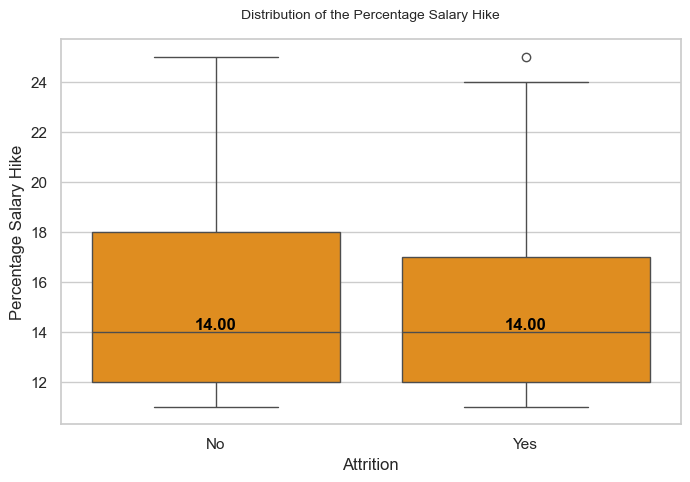

In [33]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', color='#FF9100')

medianas = df.groupby(["Attrition"])["PercentSalaryHike"].median()

for i, valor in enumerate(medianas):
    ax.text(
        i,  
        valor,  
        f"{valor:.2f}", 
        ha="center", 
        va="bottom", 
        color="black", 
        fontweight="bold", 
    )

plt.title("Distribution of the Percentage Salary Hike", fontsize=10, pad=15)
plt.xlabel("Attrition")
plt.ylabel("Percentage Salary Hike")

plt.show()

Although the median salary increase is identical for both groups (14.0%), the distribution reveals key differences. Employees who remained with the company (No) show a wider dispersion, with increases ranging from 11% to 25%, and the middle 50% of their data concentrated between 12% and 18%. In contrast, those who left the company (Yes) exhibit less variability in their increases (ranging from 11% to 17% in the main data range), with a single outlier noted at the upper end of 25%.

### **Monthly Rate**

In [34]:
df_MonthlyRate = df.groupby('Attrition')['MonthlyRate'].agg(['mean', 'median'])
df_MonthlyRate

,mean,median
Attrition,,
No,14275.753236,14159.5
Yes,14559.308017,14618.0


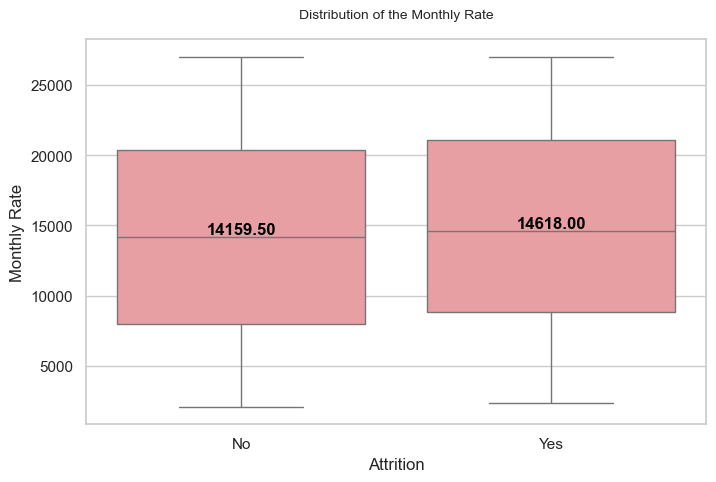

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(data=df, x='Attrition', y='MonthlyRate',color='#F39399')

medianas = df.groupby(["Attrition"])["MonthlyRate"].median()

for i, valor in enumerate(medianas):
    ax.text(
        i,  
        valor,  
        f"{valor:.2f}", 
        ha="center", 
        va="bottom", 
        color="black", 
        fontweight="bold", 
    )

plt.title("Distribution of the Monthly Rate", fontsize=10, pad=15)
plt.xlabel("Attrition") 
plt.ylabel("Monthly Rate")
plt.show()

The "Monthly Rate" indicator is defined as the total monthly cost each employee represents to the organization. A comparison of the distributions reveals a slight upward shift in the group that left the company ("Yes"), with a median of 14,618.00 compared to 14,159.50 for active staff ("No"). This difference of approximately 458 units suggests that the employees who left the company incurred a marginally higher cost; however, the significant overlap between the two groups indicates that the variation is not statistically significant.

## 😊⭐🚩**Analysis by Satisfaction and Atmosphere**

In [36]:
satisfaction_vars = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance']

results = {}

for col in satisfaction_vars:
    # Pocentaje de empleados que dejaron la empresa según cada variable de satisfacción
    results[col] = (df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100))

df_satisfaction = pd.DataFrame(results)

df_satisfaction

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance
1,25.352113,22.758621,20.577617,31.250000
2,14.982578,16.428571,14.851485,16.860465
3,13.656388,16.478555,15.434783,14.174107
4,13.392857,11.304348,14.780600,17.647059


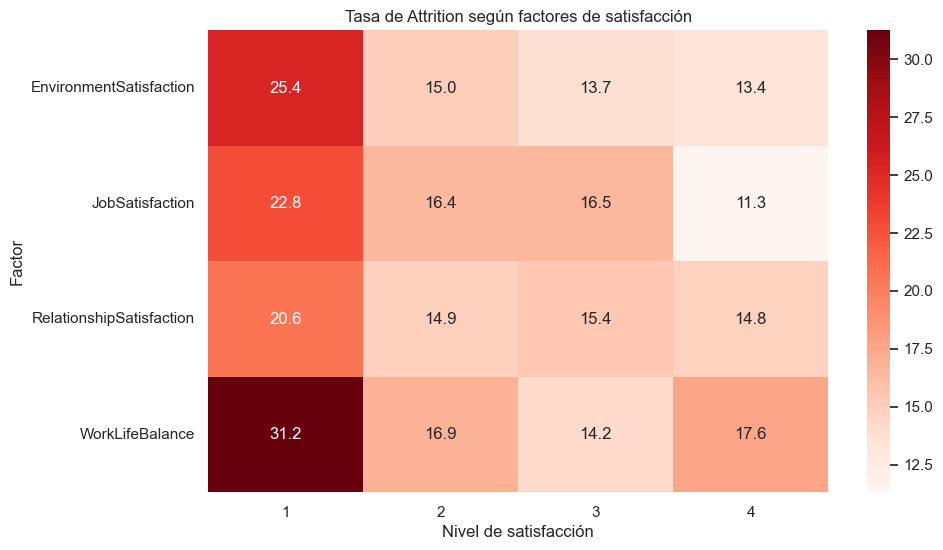

In [37]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_satisfaction.T,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Tasa de Attrition según factores de satisfacción')
plt.xlabel('Nivel de satisfacción')
plt.ylabel('Factor')

plt.show()

The heat map reveals that attrition rates reach their highest levels when satisfaction is at its lowest (Level 1). This trend is particularly critical regarding work-life balance, which records the highest rate of staff turnover at 31.2%, followed by satisfaction with the work environment at 25.4%. In contrast, as satisfaction levels rise (levels 2 through 4), attrition rates decrease significantly.

El mapa de calor revela que las tasas de deserción (Attrition) alcanzan sus niveles más altos cuando la satisfacción es mínima (Nivel 1). Este comportamiento es crítico en el factor de balance vida-trabajo (WorkLifeBalance), donde se registra la mayor fuga de personal con un 31.2%, seguido por la satisfacción con el entorno laboral (EnvironmentSatisfaction) que presenta un 25.4%. En contraste, a medida que los niveles de satisfacción aumentan (niveles 2 al 4), los porcentajes de abandono disminuyen de forma notable.

## 💼⏳**Analysis by Seniority and Track Record**

* Total Working Years
* Years At Company
* Years In Current Role
* Years Since Last Promotion
* Num Companies Worked

### **Years At Company**

In [51]:
bins = [-1, 1, 5, 10, 19, 29, np.inf]
labels = [
    '0-1',
    '2-5',
    '6-10',
    '11-19',
    '20-29',
    '30+'
]

df['CompanyTenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=bins,
    labels=labels
)

In [52]:
df['CompanyTenureGroup'].unique()

['11-19', '2-5', '0-1', '6-10', '20-29', '30+']
Categories (6, object): ['0-1' < '2-5' < '6-10' < '11-19' < '20-29' < '30+']

In [53]:
tenure_attrition = (
    df.groupby('CompanyTenureGroup', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_attrition[['Yes']]

Attrition,Yes
CompanyTenureGroup,
0-1,34.883721
2-5,15.452931
6-10,12.249443
11-19,7.189542
20-29,6.578947
30+,23.529412


C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\2823082525.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_YearsAtCompany = df.groupby('CompanyTenureGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


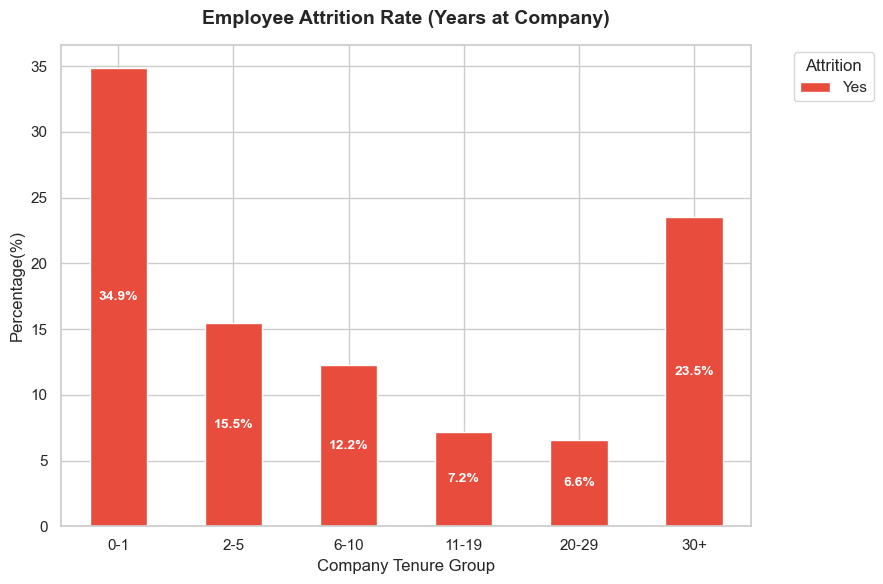

In [54]:
df_YearsAtCompany = df.groupby('CompanyTenureGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_YearsAtCompany = df_YearsAtCompany[['Yes']]
ax = df_YearsAtCompany.plot(kind='bar', stacked=True, color=[ '#e74c3c'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Employee Attrition Rate (Years at Company)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Company Tenure Group', fontsize=12)
plt.ylabel('Percentage(%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### **Years In Current Role**

In [41]:
bins = [-1, 1, 3, 6, 10, 14, np.inf]
labels = [
    '0-1',
    '2-3',
    '4-6',
    '7-10',
    '11-14',
    '15+'
]

df['CurrentRoleTenureGroup'] = pd.cut(
    df['YearsInCurrentRole'],
    bins=bins,
    labels=labels
)

In [42]:
tenure_CurrentRole = (
    df.groupby('CurrentRoleTenureGroup', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_CurrentRole[['Yes']]

Attrition,Yes
CurrentRoleTenureGroup,
0-1,27.906977
2-3,16.502947
4-6,10.169492
7-10,11.274510
11-14,5.263158
15+,9.523810


C:\Users\Portatil\AppData\Local\Temp\ipykernel_11356\1780935650.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_CurrentRole = df.groupby('CurrentRoleTenureGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


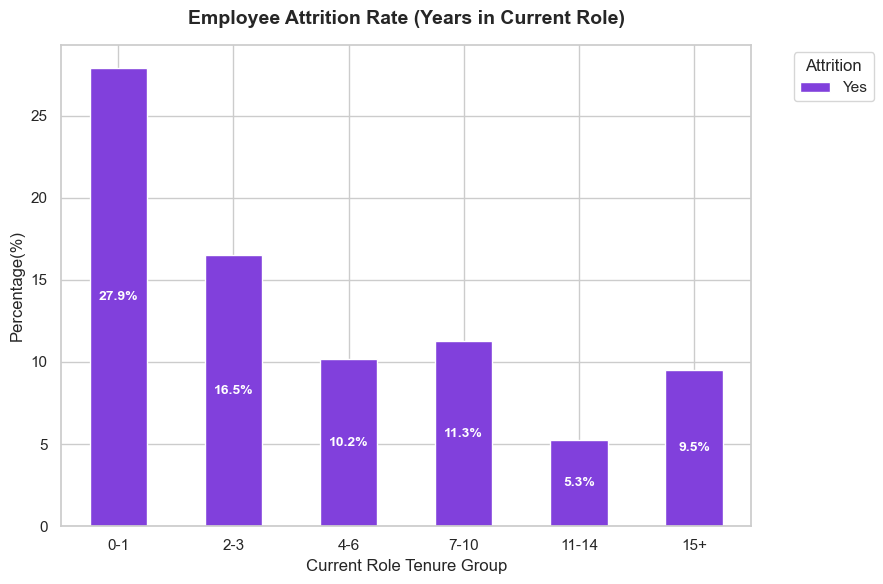

In [50]:
df_CurrentRole = df.groupby('CurrentRoleTenureGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_CurrentRole = df_CurrentRole[['Yes']]
ax = df_CurrentRole.plot(kind='bar', stacked=True, color=[ '#8140DC'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Employee Attrition Rate (Years in Current Role)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Current Role Tenure Group', fontsize=12)
plt.ylabel('Percentage(%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### **Years Since Last Promotion**

In [ ]:
# Minimo y maximo de años desde la última promoción
print(f"Maximum years since last promotion: {df['YearsSinceLastPromotion'].max()}")
print(f"Minimum years since last promotion: {df['YearsSinceLastPromotion'].min()}")

Maximum years since last promotion: 15
Minimum years since last promotion: 0


In [73]:
# Nueva columna para agrupar los años desde la última promoción
df['YearsSinceLastPromotionGroup'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[-1, 1, 3, 5, 10, 15, np.inf],
    labels=['0-1', '2-3', '4-5', '6-10', '11-15', '16+']
)

In [ ]:
# Agrupación de los datos por años desde la última promoción y cálculo del porcentaje de rotación
tenure_LastPromotion = (
    df.groupby('YearsSinceLastPromotionGroup', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_LastPromotion[['Yes']]

Attrition,Yes
YearsSinceLastPromotionGroup,
0-1,16.896918
2-3,17.061611
4-5,6.603774
6-10,18.120805
11-15,12.121212


C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\3576679845.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_LastPromotion = df.groupby('YearsSinceLastPromotionGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


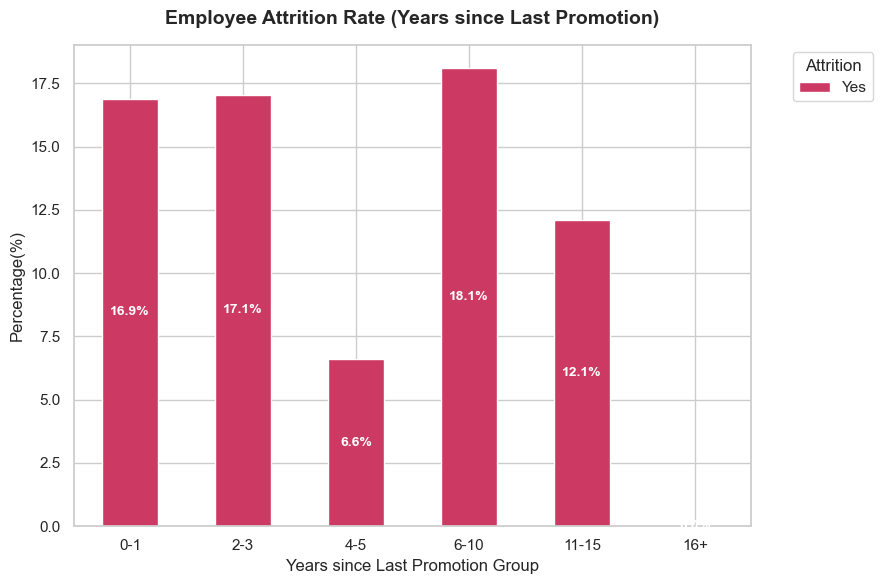

In [68]:
df_LastPromotion = df.groupby('YearsSinceLastPromotionGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_LastPromotion = df_LastPromotion[['Yes']]
ax = df_LastPromotion.plot(kind='bar', stacked=True, color=[ '#CC3A63'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Employee Attrition Rate (Years since Last Promotion)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Years since Last Promotion Group', fontsize=12)
plt.ylabel('Percentage(%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Total Working Years**

In [71]:
# Minimo y maximo de los años trabajados
print(f"Maximum year of total working years: {df['TotalWorkingYears'].max()}")
print(f"Minimum year of total working years: {df['TotalWorkingYears'].min()}")

Maximum year of total working years: 40
Minimum year of total working years: 0


In [74]:
# Nueva columna para agrupar el total de años trabajados
df['TotalWorkingYearsGroup'] = pd.cut(
    df['TotalWorkingYears'],
    bins=[-1, 5, 10, 15, 20, 25, np.inf],
    labels=['0-5', '6-10', '11-15', '16-20', '21-25', '26+'])

In [75]:
# Agrupación de los datos por años trabajados y cálculo del porcentaje de rotación
tenure_TotalWorkingYears = (
    df.groupby('TotalWorkingYearsGroup', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_TotalWorkingYears[['Yes']]   

Attrition,Yes
TotalWorkingYearsGroup,
0-5,28.706625
6-10,14.967105
11-15,12.565445
16-20,10.000000
21-25,8.256881
26+,7.142857


C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\652305855.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_TotalWorkingYears = df.groupby('TotalWorkingYearsGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


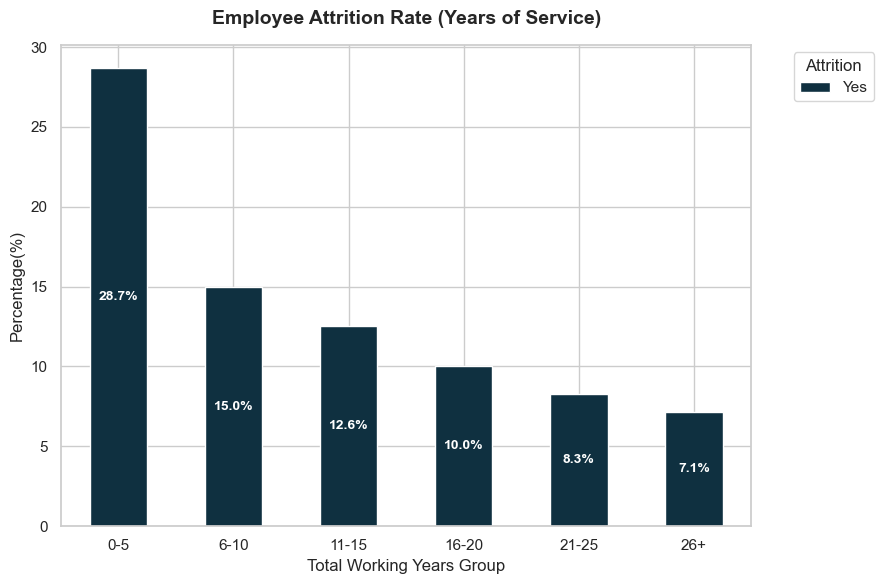

In [77]:
df_TotalWorkingYears = df.groupby('TotalWorkingYearsGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_TotalWorkingYears = df_TotalWorkingYears[['Yes']]
ax = df_TotalWorkingYears.plot(kind='bar', stacked=True, color=[ '#0F3040'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Employee Attrition Rate (Years of Service)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Working Years Group', fontsize=12)
plt.ylabel('Percentage(%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Num Companies Worked For**

In [78]:
# Maximum and minimum number of companies worked for
print(f"Maximum number of companies worked for: {df['NumCompaniesWorked'].max()}")
print(f"Minimum number of companies worked for: {df['NumCompaniesWorked'].min()}")

Maximum number of companies worked for: 9
Minimum number of companies worked for: 0


In [80]:
# Nueva columna para agrupar el total de compañias en el que ha trabajado el empleado
df['NumberCompaniesWorkedGroup'] = pd.cut(
    df['NumCompaniesWorked'],
    bins=[-1, 1, 2, 3, 4, 5, np.inf],
    labels=['0', '1', '2', '3', '4', '5+'])

In [81]:
# Agrupación del numero de compañias trabajadas y cálculo del porcentaje de rotación
tenure_NumberCompaniesWorked = (
    df.groupby('NumberCompaniesWorkedGroup', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack() * 100
)

tenure_NumberCompaniesWorked[['Yes']]   

Attrition,Yes
NumberCompaniesWorkedGroup,
0,16.828929
1,10.958904
2,10.062893
3,12.056738
4,25.396825
5+,20.816327


C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\3819743684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_NumberCompaniesWorked = df.groupby('NumberCompaniesWorkedGroup')['Attrition'].value_counts(normalize=True).unstack() * 100


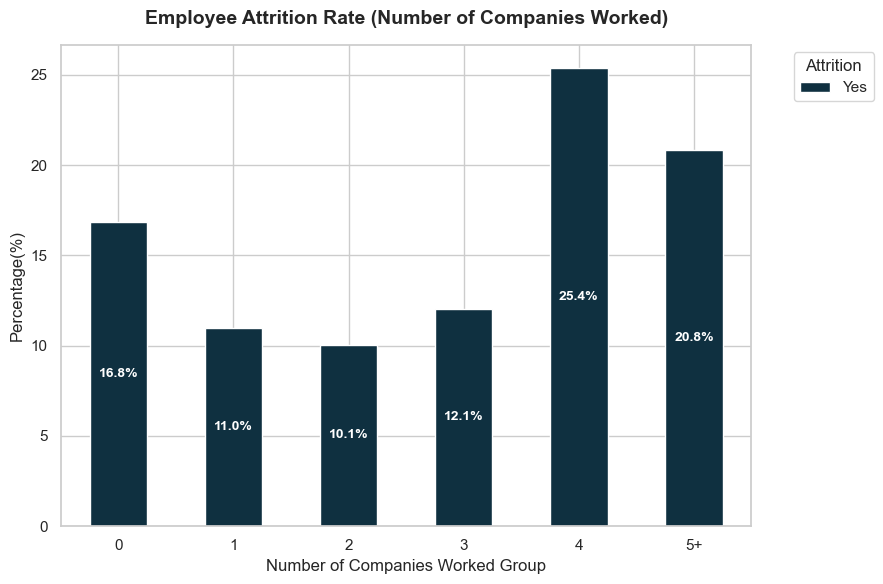

In [82]:
df_NumberCompaniesWorked = df.groupby('NumberCompaniesWorkedGroup')['Attrition'].value_counts(normalize=True).unstack() * 100
df_NumberCompaniesWorked = df_NumberCompaniesWorked[['Yes']]
ax = df_NumberCompaniesWorked.plot(kind='bar', stacked=True, color=[ '#0F3040'], figsize=(9, 6))

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)

plt.title('Employee Attrition Rate (Number of Companies Worked)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Companies Worked Group', fontsize=12)
plt.ylabel('Percentage(%)', fontsize=12)
plt.xticks(rotation=0) 
plt.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\437776408.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100


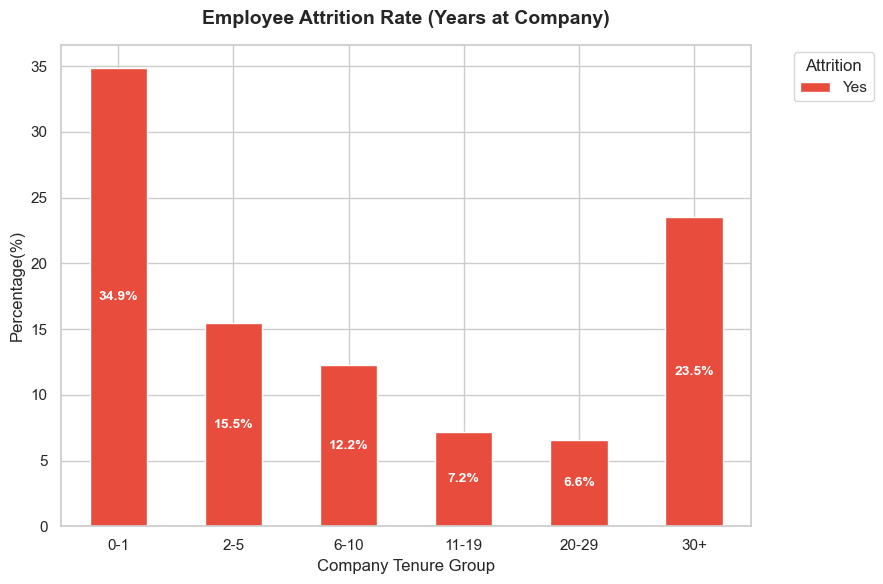

C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\437776408.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100


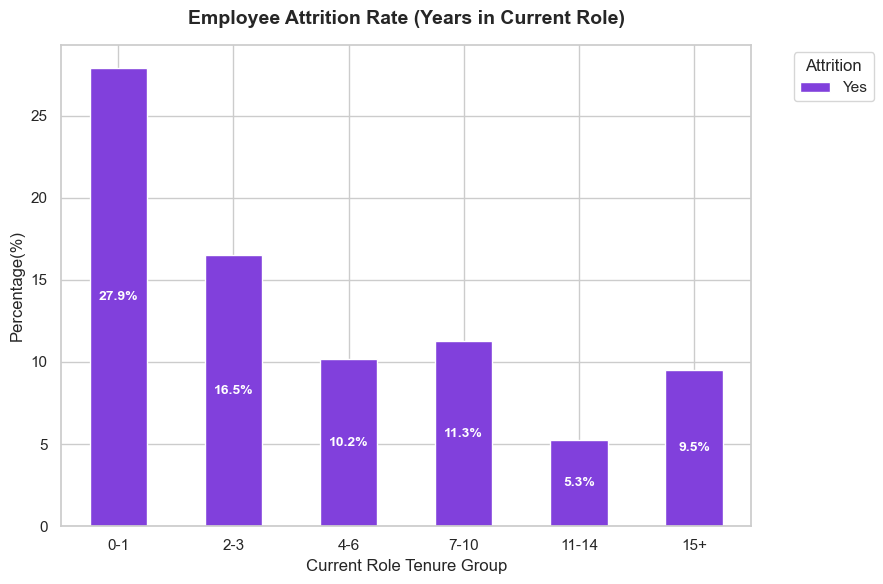

C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\437776408.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100


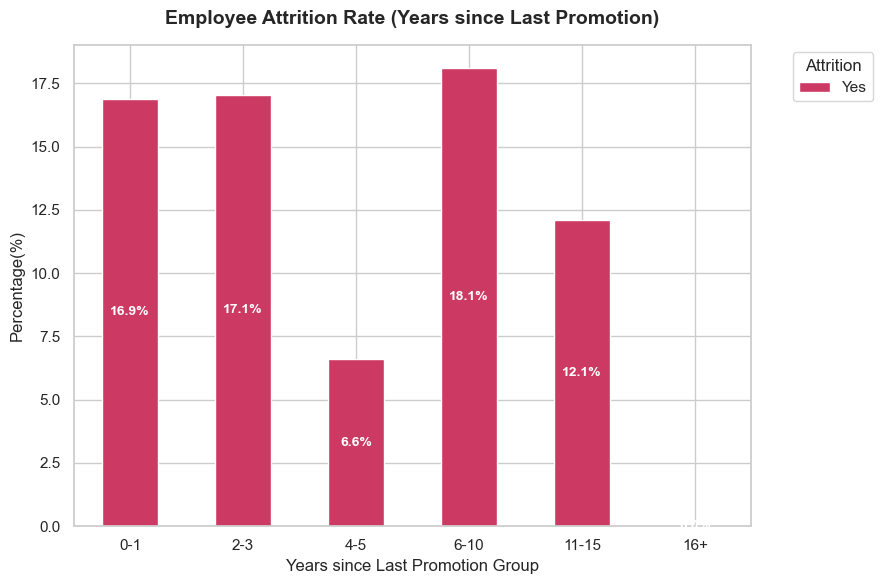

C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\437776408.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100


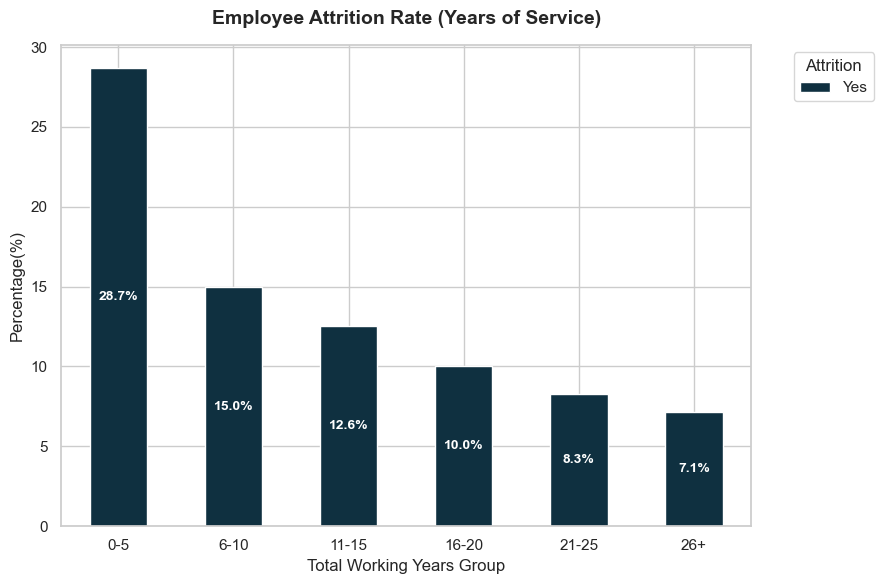

C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\437776408.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100


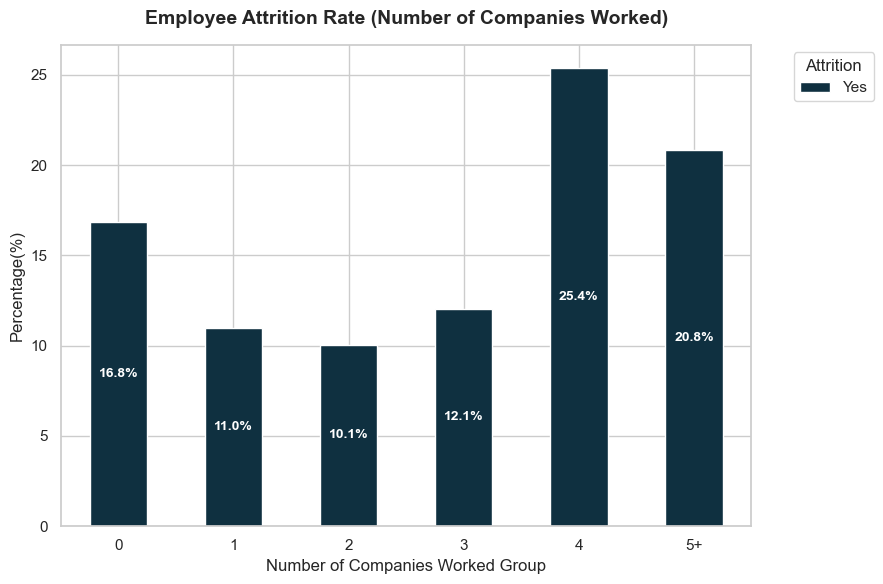

In [94]:
import matplotlib.pyplot as plt

# 1. Definir la configuración de cada gráfica (Columna, Color y Título)
analisis_config = [
    {
        'columna': 'CompanyTenureGroup', 
        'color': '#e74c3c', 
        'titulo': 'Employee Attrition Rate (Years at Company)', 
        'eje_x': 'Company Tenure Group'
    },
    {
        'columna': 'CurrentRoleTenureGroup', 
        'color': '#8140DC', 
        'titulo': 'Employee Attrition Rate (Years in Current Role)', 
        'eje_x': 'Current Role Tenure Group'
    },
    {
        'columna': 'YearsSinceLastPromotionGroup', 
        'color': '#CC3A63', 
        'titulo': 'Employee Attrition Rate (Years since Last Promotion)', 
        'eje_x': 'Years since Last Promotion Group'
    },
    {
        'columna': 'TotalWorkingYearsGroup', 
        'color': '#0F3040', 
        'titulo': 'Employee Attrition Rate (Years of Service)', 
        'eje_x': 'Total Working Years Group'
    },
    {
        'columna': 'NumberCompaniesWorkedGroup', 
        'color': '#0F3040', 
        'titulo': 'Employee Attrition Rate (Number of Companies Worked)', 
        'eje_x': 'Number of Companies Worked Group'
    }
]

# 2. Bucle para generar y mostrar cada gráfico de forma automática
for config in analisis_config:
    # Agrupar datos y calcular porcentajes
    df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(9, 6))
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax)
    
    # Añadir etiquetas de porcentaje dentro de las barras
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    # Personalizar diseño y textos
    ax.set_title(config['titulo'], fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(config['eje_x'], fontsize=12)
    ax.set_ylabel('Percentage(%)', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajustar y mostrar
    plt.tight_layout()
    plt.show()


C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\949975444.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100
C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\949975444.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100
C:\Users\Portatil\AppData\Local\Temp\ipykernel_10180\949975444.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

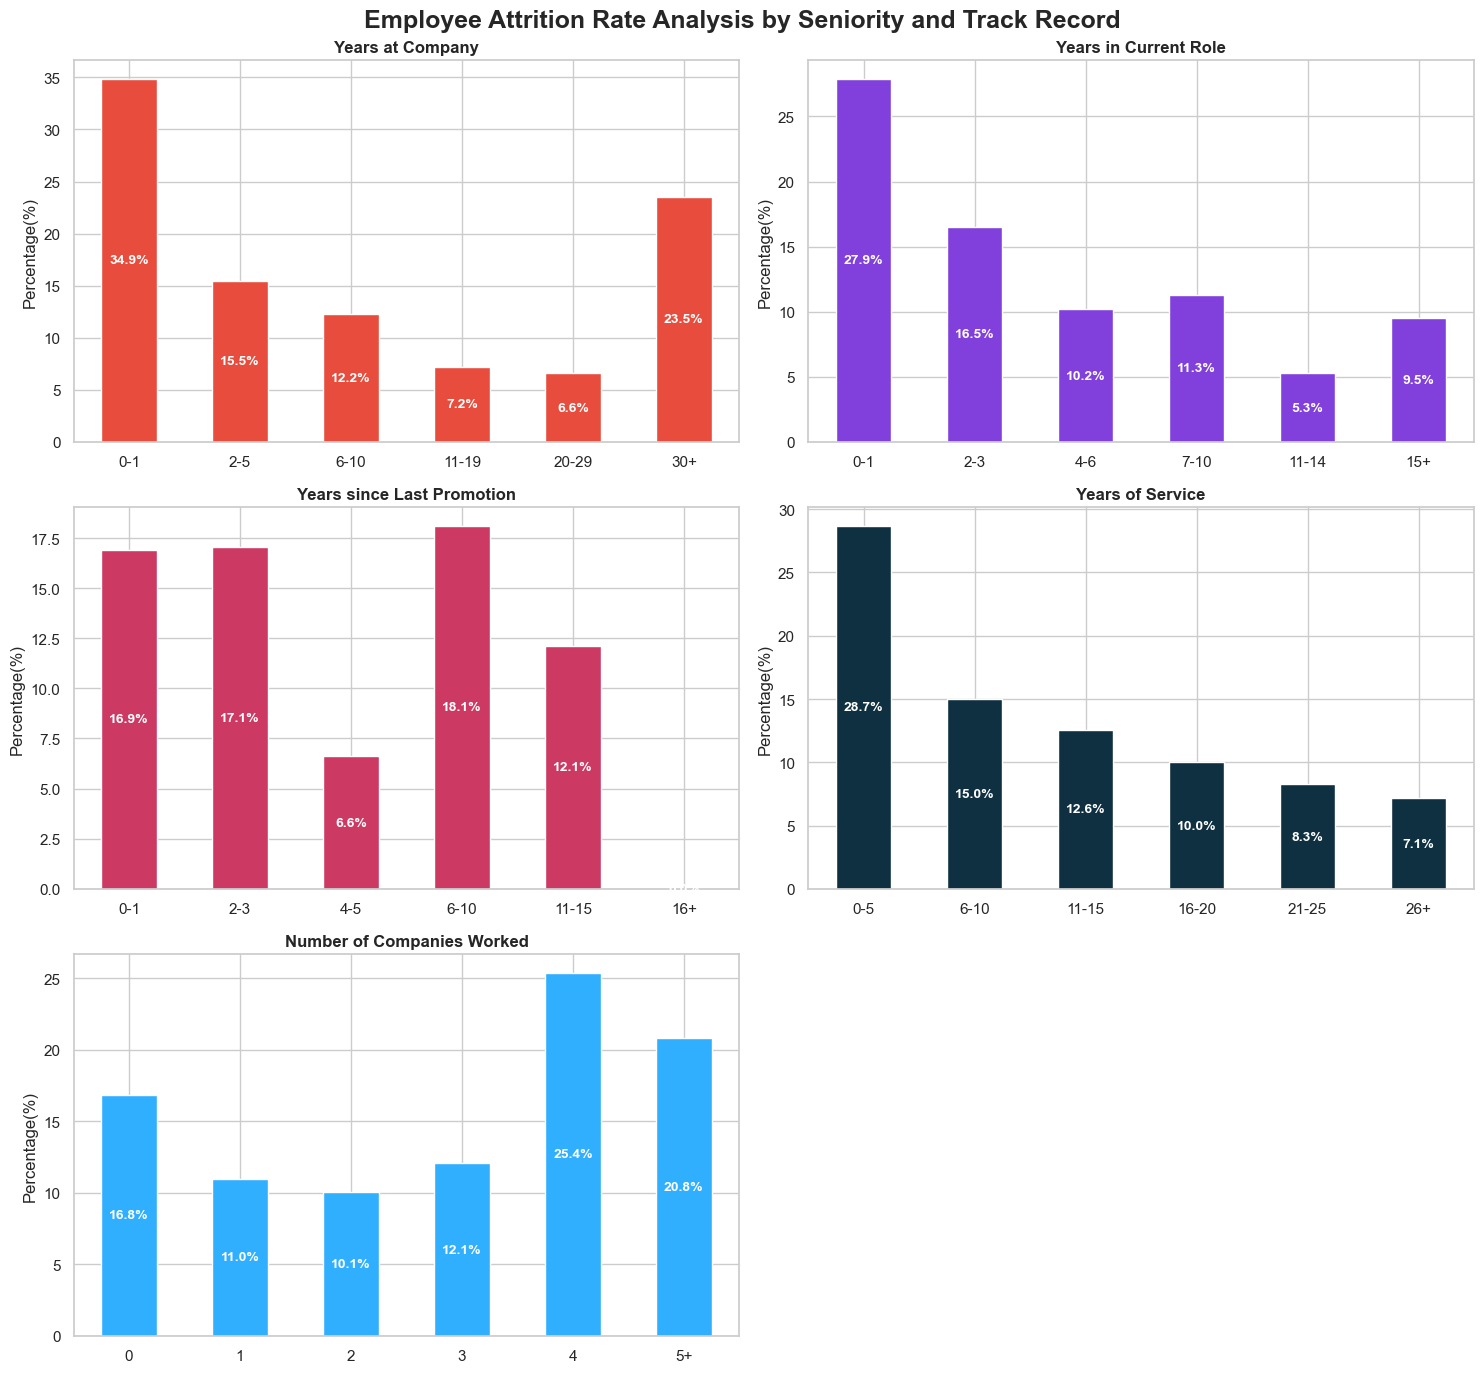

In [97]:
import matplotlib.pyplot as plt

# Configuración idéntica a tu diseño original
analisis_config = [
    {'columna': 'CompanyTenureGroup', 'color': '#e74c3c', 'titulo': 'Years at Company'},
    {'columna': 'CurrentRoleTenureGroup', 'color': '#8140DC', 'titulo': 'Years in Current Role'},
    {'columna': 'YearsSinceLastPromotionGroup', 'color': '#CC3A63', 'titulo': 'Years since Last Promotion'},
    {'columna': 'TotalWorkingYearsGroup', 'color': '#0F3040', 'titulo': 'Years of Service'},
    {'columna': 'NumberCompaniesWorkedGroup', 'color': '#30AFFF', 'titulo': 'Number of Companies Worked'}
]

# Crear una cuadrícula de 3 filas y 2 columnas en una sola figura
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple

# Bucle para dibujar cada gráfico en su celda correspondiente
for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    # Calcular porcentajes
    df_grouped = df.groupby(config['columna'])['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    # Dibujar en el eje específico de la cuadrícula
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax, legend=False)
    
    # Etiquetas de porcentaje dentro de las barras
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    # Configuración de textos del subgráfico
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage(%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Ocultar el sexto subgráfico vacío de la esquina inferior derecha
axes[-1].axis('off')

# Añadir un título principal a toda la imagen combinada
fig.suptitle('Employee Attrition Rate Analysis by Seniority and Track Record', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


## 🛠️💼⏳**Analysis by Labor Factors**

* Business Travel
* Over Time
* Distance FromHome
* Num Companies Worked
* Training Times Last Year

### **Analysis by Overtime**
**¿Existe una mayor proporción de rotación entre empleados que realizan horas extra?**

In [87]:
df_overtime_attrition = (df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100)
df_overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.593188,10.406812
Yes,69.471154,30.528846


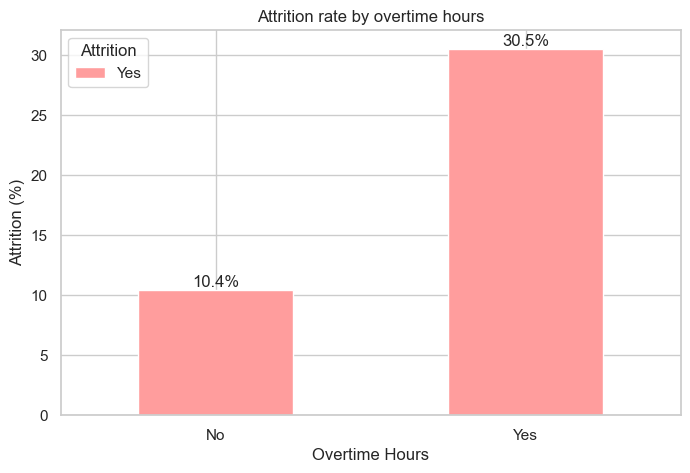

In [91]:
ax = df_overtime_attrition[['Yes']].plot(kind='bar', figsize=(8,5), color=['#FF9D9D'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')

plt.title('Attrition rate by overtime hours')
plt.xlabel('Overtime Hours')
plt.ylabel('Attrition (%)')
plt.xticks(rotation=0)
plt.show()


The analysis reveals that working overtime is a key factor in staff turnover. The attrition rate triples, rising from 10.4% among employees who do not work overtime to 30.5% among those who do.

### **Analysis by Distance from Home**

In [93]:
print("Maximum of distance from home: ", df['DistanceFromHome'].max())
print("Minimum of distance from home: ", df['DistanceFromHome'].min())

Maximum of distance from home:  29
Minimum of distance from home:  1
